In [ ]:
import pandas as pd, numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn import tree
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns, warnings
import tkinter as tk
from tkinter import ttk, messagebox

warnings.filterwarnings("ignore")

In [ ]:
# Read and display dataset info
dataset = pd.read_csv('train_weather.csv')
print("Dataset shape:", dataset.shape)
print("\nMissing values per column:\n", dataset.isnull().sum().to_string())

# Define targets and results storage
targets = ['RainToday', 'RainTomorrow']
results = {}

Dataset shape: (121873, 22)

Missing values per column:
 Location             0
MinTemp           1221
MaxTemp           1031
Rainfall          2728
Evaporation      50544
Sunshine         56175
WindGustDir       8716
WindGustSpeed     8661
WindDir9am        8914
WindDir3pm        3354
WindSpeed9am      1519
WindSpeed3pm      2345
Humidity9am       2231
Humidity3pm       3382
Pressure9am      12635
Pressure3pm      12602
Cloud9am         46059
Cloud3pm         48476
Temp9am           1533
Temp3pm           2656
RainToday            0
RainTomorrow         0


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Brisbane,13.7,23.6,0.0,5.0,9.6,SSE,24.0,SSW,ESE,...,65.0,53.0,1028.4,1026.7,1.0,1.0,18.3,22.3,0,0
1,Sydney,15.4,21.2,61.2,5.8,2.7,S,43.0,WSW,SSW,...,91.0,65.0,1018.8,1016.5,8.0,7.0,15.6,20.7,1,1
2,Richmond,16.8,30.9,1.0,NaN,NaN,NE,35.0,NNW,NE,...,80.0,38.0,1020.4,1013.2,1.0,NaN,19.6,30.0,0,0
3,NorfolkIsland,13.9,17.1,0.2,3.8,8.9,SE,37.0,SE,SSE,...,56.0,63.0,1027.7,1026.1,3.0,1.0,15.3,15.8,0,0
4,Mildura,16.0,36.1,0.0,6.8,12.9,ENE,33.0,ENE,E,...,58.0,32.0,1018.5,1016.0,0.0,3.0,26.0,34.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121868,GoldCoast,17.6,25.1,0.0,NaN,NaN,SSE,56.0,SE,E,...,58.0,58.0,1012.8,1010.2,NaN,NaN,23.5,24.2,0,0
121869,Adelaide,15.1,25.2,0.0,10.0,11.3,SW,48.0,S,WSW,...,55.0,41.0,1018.8,1018.3,NaN,NaN,19.0,24.6,0,0
121870,MountGinini,10.5,18.4,1.2,NaN,NaN,SSE,50.0,E,E,...,97.0,93.0,NaN,NaN,NaN,NaN,12.5,15.9,1,1
121871,Adelaide,13.6,19.8,2.6,NaN,7.5,WSW,54.0,WSW,WSW,...,76.0,46.0,1008.5,1007.4,NaN,NaN,14.4,18.9,1,1


In [36]:
def train_models_for_target(target):
    """
    Train and evaluate all models for a given target
    """
    print(f"\n===== Processing {target} =====")
    
    # Prepare data (encode, impute, split, scale)
    Y = dataset[target].values
    X = dataset.drop(targets, axis=1)
    for col in ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    
    X = SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(X.values)
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

    sc_X = StandardScaler()
    x_train, x_test = sc_X.fit_transform(x_train), sc_X.transform(x_test)
    
    print("\nClass distribution:\n", pd.Series(y_train).value_counts().to_string())
    
    # Define models
    models = {
        'Decision Tree': tree.DecisionTreeClassifier(criterion='entropy', random_state=0),
        'Neural Network': MLPClassifier(random_state=0, max_iter=50),
        'Naive Bayes': GaussianNB(),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=0, 
                                        class_weight=dict(zip(np.unique(y_train), 
                                        compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=0)
    }
    
    # Train and Test models
    model_results = {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        accuracy = accuracy_score(y_pred, y_test)
        model_results[name] = {'model': model, 'accuracy': accuracy, 'predictions': y_pred}
        print(f"{name} Accuracy: {accuracy:.4f}")
    
    # Print best model report
    best_model_name = max(model_results.keys(), key=lambda k: model_results[k]['accuracy'])
    print(f"\nClassification Report for Best Model ({best_model_name}):")
    print(classification_report(y_test, model_results[best_model_name]['predictions']))
    
    return model_results, x_train, x_test, y_train, y_test

In [37]:
# Process RainToday target
results['RainToday'], x_train_today, x_test_today, y_train_today, y_test_today = train_models_for_target('RainToday')


===== Processing RainToday =====

Class distribution:
 0    75842
1    21656
Decision Tree Accuracy: 1.0000
Neural Network Accuracy: 0.9925
Naive Bayes Accuracy: 0.9332
Random Forest Accuracy: 0.9997
Gradient Boosting Accuracy: 1.0000

Classification Report for Best Model (Decision Tree):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19165
           1       1.00      1.00      1.00      5210

    accuracy                           1.00     24375
   macro avg       1.00      1.00      1.00     24375
weighted avg       1.00      1.00      1.00     24375



In [38]:
# Process RainTomorrow target
results['RainTomorrow'], x_train_tomorrow, x_test_tomorrow, y_train_tomorrow, y_test_tomorrow = train_models_for_target('RainTomorrow')


===== Processing RainTomorrow =====

Class distribution:
 0    75952
1    21546
Decision Tree Accuracy: 0.7860
Neural Network Accuracy: 0.8532
Naive Bayes Accuracy: 0.8057
Random Forest Accuracy: 0.8519
Gradient Boosting Accuracy: 0.8476

Classification Report for Best Model (Neural Network):
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     19063
           1       0.74      0.50      0.60      5312

    accuracy                           0.85     24375
   macro avg       0.81      0.73      0.75     24375
weighted avg       0.84      0.85      0.84     24375



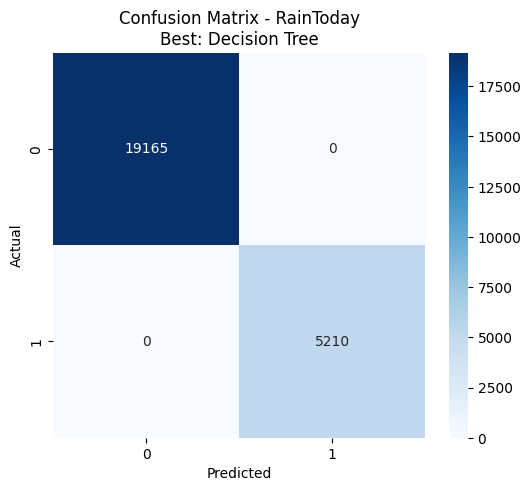

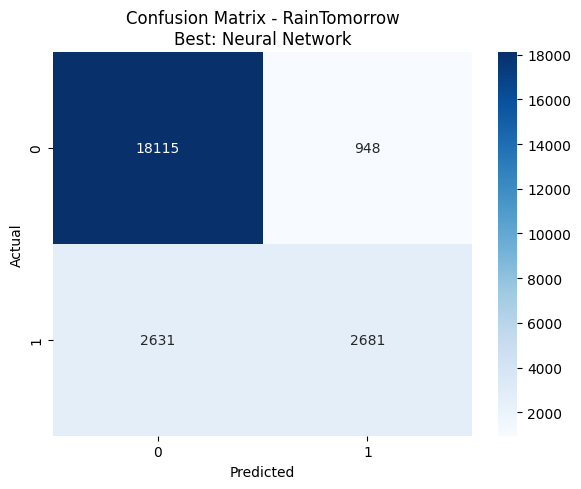

In [39]:
# Plot confusion matrices
for i, target in enumerate(targets):
    plt.figure(figsize=(6, 5))
    best_model_name = max(results[target].keys(), key=lambda k: results[target][k]['accuracy'])
    y_pred = results[target][best_model_name]['predictions']
    
    # Use the correct test data for each target
    if target == 'RainToday':
        y_test = y_test_today
    else:  # RainTomorrow
        y_test = y_test_tomorrow
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {target}\nBest: {best_model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

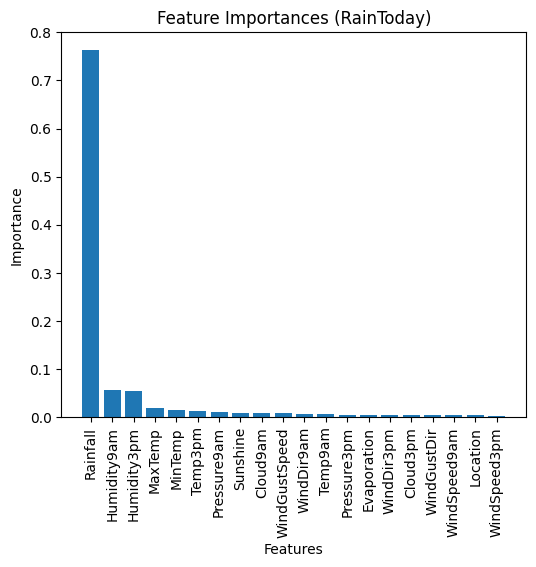

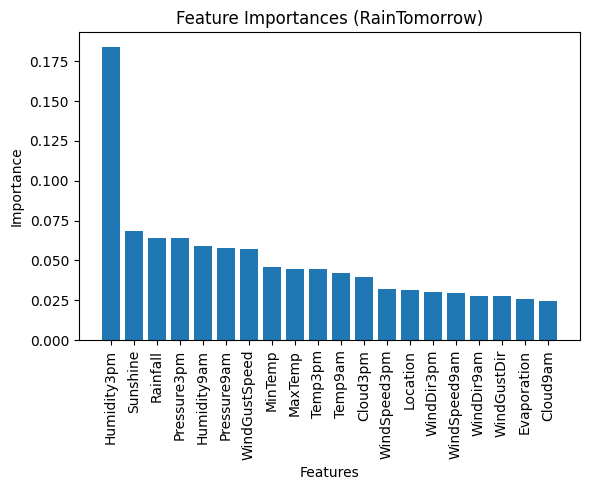


Top 10 Most Important Features for RainToday:
1. Rainfall: 0.7625
2. Humidity9am: 0.0555
3. Humidity3pm: 0.0533
4. MaxTemp: 0.0184
5. MinTemp: 0.0157
6. Temp3pm: 0.0131
7. Pressure9am: 0.0108
8. Sunshine: 0.0089
9. Cloud9am: 0.0077
10. WindGustSpeed: 0.0075

Top 10 Most Important Features for RainTomorrow:
1. Humidity3pm: 0.1839
2. Sunshine: 0.0684
3. Rainfall: 0.0643
4. Pressure3pm: 0.0638
5. Humidity9am: 0.0589
6. Pressure9am: 0.0581
7. WindGustSpeed: 0.0570
8. MinTemp: 0.0460
9. MaxTemp: 0.0446
10. Temp3pm: 0.0444


In [40]:
# Plot feature importances for both targets
for i, target in enumerate(targets):
    plt.figure(figsize=(6, 5))
    rf_model = results[target]['Random Forest']['model']
    feature_importances = rf_model.feature_importances_
    indices = np.argsort(feature_importances)[::-1]
    feature_names = dataset.drop(targets, axis=1).columns
    
    plt.title(f'Feature Importances ({target})')
    plt.bar(range(len(feature_importances)), feature_importances[indices], align='center')
    plt.xticks(range(len(feature_importances)),
               [feature_names[j] for j in indices],
               rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance')

plt.tight_layout()
plt.show()

# Print top 10 features for each target
for target in targets:
    print(f"\nTop 10 Most Important Features for {target}:")
    rf_model = results[target]['Random Forest']['model']
    feature_importances = rf_model.feature_importances_
    indices = np.argsort(feature_importances)[::-1]
    feature_names = dataset.drop(targets, axis=1).columns

    for i in range(min(10, len(feature_importances))):
        print(f"{i+1}. {feature_names[indices[i]]}: {feature_importances[indices[i]]:.4f}")


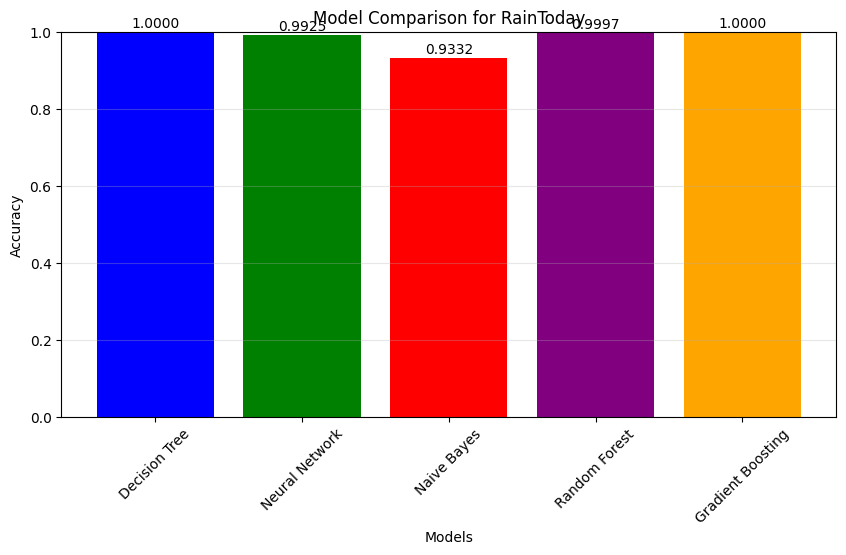

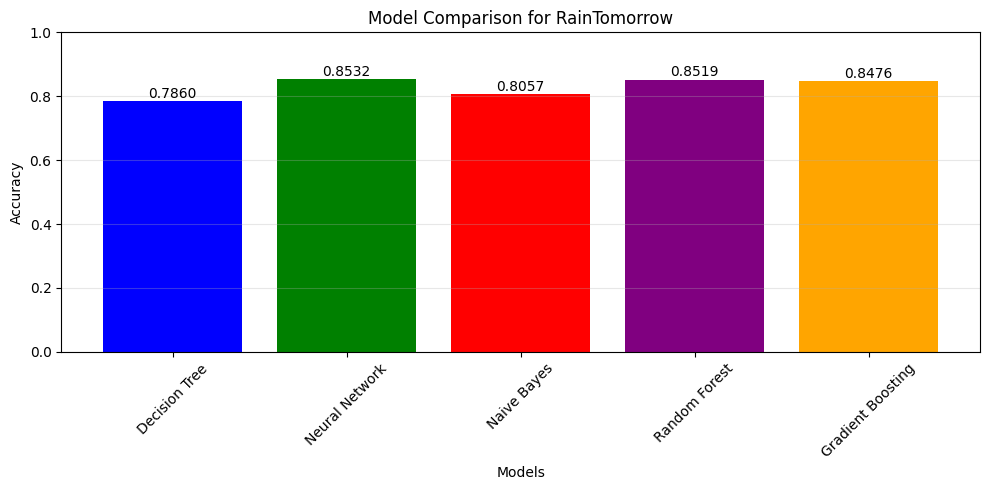

In [41]:
# Plot model comparison
for i, target in enumerate(targets):
    plt.figure(figsize=(10, 5))
    model_names = list(results[target].keys())
    accuracies = [results[target][name]['accuracy'] for name in model_names]
    plt.bar(model_names, accuracies, color=['blue', 'green', 'red', 'purple', 'orange', 'cyan', 'magenta'])
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.title(f'Model Comparison for {target}')
    plt.ylim(0, 1)
    for j, v in enumerate(accuracies):
        plt.text(j, v + 0.01, f"{v:.4f}", ha='center')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 2000x1400 with 0 Axes>

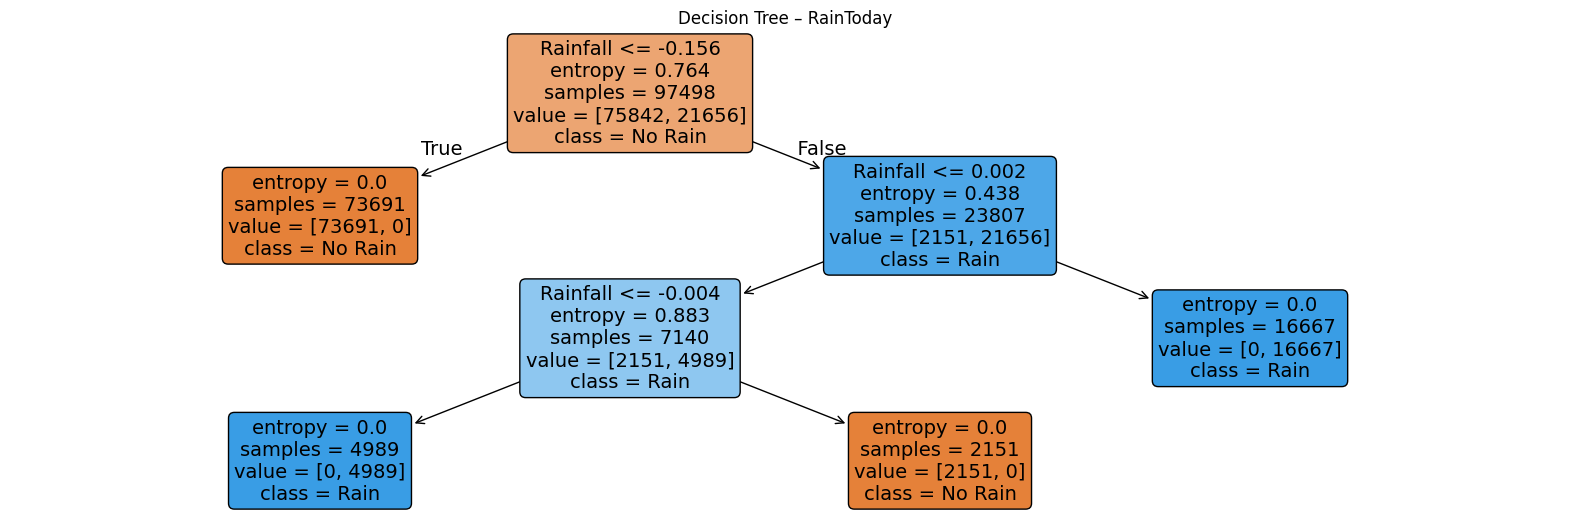

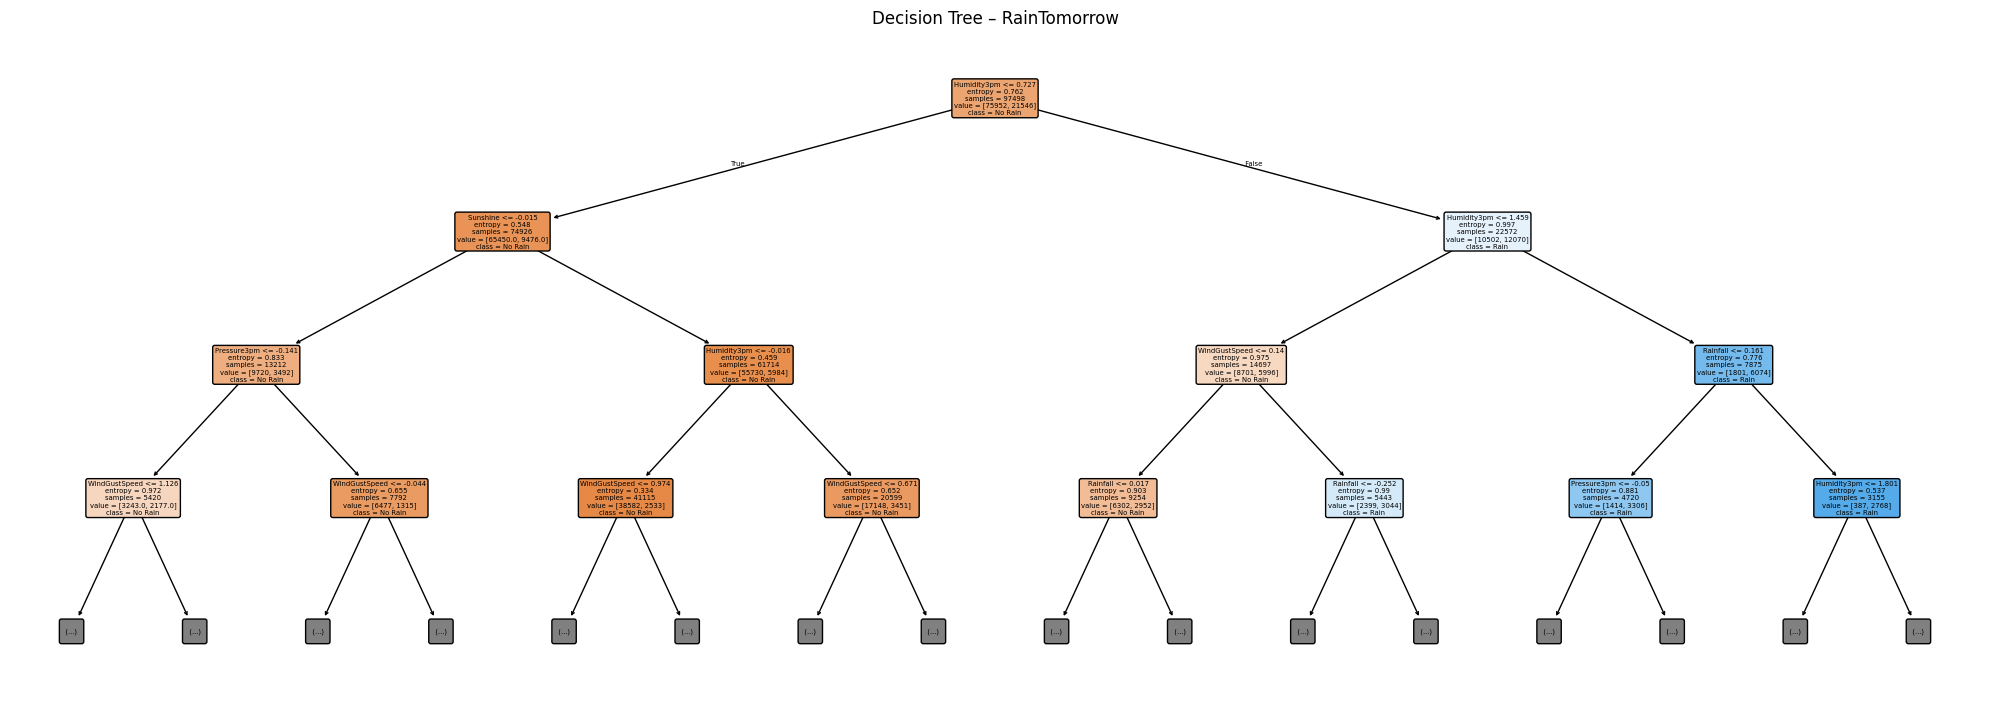

In [46]:
plt.figure(figsize=(20, 14))

for i, target in enumerate(targets):
    dt_model = results[target]['Decision Tree']['model']

    plt.figure(figsize=(20, 14))
    plt.subplot(2, 1, i + 1)
    tree.plot_tree(
        dt_model,
        feature_names=dataset.drop(targets, axis=1).columns,
        class_names=['No Rain', 'Rain'],
        filled=True,
        rounded=True,
        max_depth=3  # limit depth so it’s readable
    )
    plt.title(f'Decision Tree – {target}')

plt.tight_layout()
plt.show()

In [43]:
# Print summary
print("\n=== MODEL COMPARISON SUMMARY ===")
for target in targets:
    print(f"\n--- {target} ---")
    for name, data in results[target].items():
        print(f"{name}: {data['accuracy']:.4f}")


=== MODEL COMPARISON SUMMARY ===

--- RainToday ---
Decision Tree: 1.0000
Neural Network: 0.9925
Naive Bayes: 0.9332
Random Forest: 0.9997
Gradient Boosting: 1.0000

--- RainTomorrow ---
Decision Tree: 0.7860
Neural Network: 0.8532
Naive Bayes: 0.8057
Random Forest: 0.8519
Gradient Boosting: 0.8476


In [54]:
sc_X = StandardScaler()
# ===== Feature names =====
feature_names = list(dataset.drop(targets, axis=1).columns)

# ===== Location values (same order as LabelEncoder) =====
locations = sorted(dataset['Location'].astype(str).unique())
location_to_code = {loc: i for i, loc in enumerate(locations)}

# ===== Get best model for each target =====
best_models = {}
for target in targets:
    best_name = max(results[target], key=lambda k: results[target][k]['accuracy'])
    best_models[target] = results[target][best_name]['model']

# ===== GUI =====
root = tk.Tk()
root.title("Rain Prediction System")
root.geometry("520x750")

entries = {}

tk.Label(root, text="Enter Weather Features", font=("Arial", 14, "bold")).pack(pady=10)

form_frame = tk.Frame(root)
form_frame.pack(padx=10)

# ===== Create input fields =====
for feature in feature_names:
    row = tk.Frame(form_frame)
    row.pack(fill="x", pady=3)

    tk.Label(row, text=feature, width=18, anchor="w").pack(side="left")

    # Location dropdown
    if feature == "Location":
        location_var = tk.StringVar(value=locations[0])
        dropdown = ttk.Combobox(
            row,
            textvariable=location_var,
            values=locations,
            state="readonly"
        )
        dropdown.pack(side="right", fill="x", expand=True)
        entries[feature] = location_var
    else:
        entry = tk.Entry(row)
        entry.pack(side="right", fill="x", expand=True)
        entries[feature] = entry

# ===== Target selection =====
tk.Label(root, text="Select Target", font=("Arial", 12, "bold")).pack(pady=10)

target_var = tk.StringVar(value="RainTomorrow")
target_menu = ttk.Combobox(
    root,
    textvariable=target_var,
    values=targets,
    state="readonly"
)
target_menu.pack()

# ===== Prediction function =====
def predict():
    try:
        input_data = []

        for feature in feature_names:
            if feature == "Location":
                loc_name = entries[feature].get()
                value = location_to_code[loc_name]
            else:
                value = float(entries[feature].get())
            input_data.append(value)

        input_array = np.array(input_data).reshape(1, -1)

        # Scale input
        input_array = sc_X.fit_transform(input_array)

        # Predict
        target = target_var.get()
        model = best_models[target]
        prediction = model.predict(input_array)[0]

        result = "Rain" if prediction == 1 else "No Rain"
        messagebox.showinfo("Prediction Result", f"{target}: {result}")

    except Exception as e:
        messagebox.showerror("Error", str(e))

# ===== Predict button (VISIBLE & CLEAR) =====
tk.Button(
    root,
    text="PREDICT",
    font=("Arial", 14, "bold"),
    bg="#4CAF50",
    fg="white",
    height=2,
    command=predict
).pack(pady=25)

root.mainloop()